In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR="../../data/nhanes/"

In [3]:
TABLE_NAMES = [
    "DEMO_L", "DPQ_L", "SLQ_L", "PAQ_L", "ALQ_L",
    "SMQ_L", "INQ_L", "HIQ_L", "DIQ_L", "BMX_L"
]

In [4]:
tables={}

for name in TABLE_NAMES:
    df=pd.read_sas(DATA_DIR+name+".xpt",format="xport", encoding="utf-8")
    tables[name]=df
    print(f"{name} shape: {df.shape}")
    # print(f"columns: {df.columns}\n")

DEMO_L shape: (11933, 27)
DPQ_L shape: (6337, 11)
SLQ_L shape: (8501, 7)
PAQ_L shape: (8153, 8)
ALQ_L shape: (6337, 9)
SMQ_L shape: (9015, 9)
INQ_L shape: (11933, 5)
HIQ_L shape: (11933, 11)
DIQ_L shape: (11744, 9)
BMX_L shape: (8860, 22)


# 1.DEMO_L
+ SEQN - 受访者序列号
+ RIAGENDR——性别
+ RIDAGEYR - 筛查时的年龄（岁）
+ RIDRETH3 - 种族/西班牙裔血统 w/ 非西班牙裔亚洲人

In [6]:
demo=tables['DEMO_L']
demo.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60


In [7]:
demo.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4',
       'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND',
       'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR',
       'SDMVSTRA', 'SDMVPSU', 'INDFMPIR'],
      dtype='object')

In [8]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      11933 non-null  float64
 1   SDDSRVYR  11933 non-null  float64
 2   RIDSTATR  11933 non-null  float64
 3   RIAGENDR  11933 non-null  float64
 4   RIDAGEYR  11933 non-null  float64
 5   RIDAGEMN  377 non-null    float64
 6   RIDRETH1  11933 non-null  float64
 7   RIDRETH3  11933 non-null  float64
 8   RIDEXMON  8860 non-null   float64
 9   RIDEXAGM  2787 non-null   float64
 10  DMQMILIZ  8301 non-null   float64
 11  DMDBORN4  11914 non-null  float64
 12  DMDYRUSR  1875 non-null   float64
 13  DMDEDUC2  7794 non-null   float64
 14  DMDMARTZ  7792 non-null   float64
 15  RIDEXPRG  1503 non-null   float64
 16  DMDHHSIZ  11933 non-null  float64
 17  DMDHRGND  4115 non-null   float64
 18  DMDHRAGZ  4124 non-null   float64
 19  DMDHREDZ  3746 non-null   float64
 20  DMDHRMAZ  4020 non-null   fl

In [9]:
demo.describe()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
count,11933.000000,11933.0,11933.000000,11933.000000,1.193300e+04,3.770000e+02,11933.000000,11933.000000,8860.000000,2.787000e+03,...,4115.000000,4124.000000,3746.000000,4020.000000,2127.000000,11933.000000,1.193300e+04,11933.000000,11933.000000,9.892000e+03
mean,136344.000000,12.0,1.742479,1.532808,3.831786e+01,1.162865e+01,3.104584,3.320540,1.520203,1.219085e+02,...,1.564277,2.539525,2.171383,1.381095,2.275035,27404.135674,2.740414e+04,179.918294,1.491746,2.708174e+00
std,3444.904716,0.0,0.437287,0.498943,2.560199e+01,6.805429e+00,1.076346,1.518379,0.499620,6.715865e+01,...,0.495912,0.641094,0.660132,0.681421,0.694050,19449.155209,2.796296e+04,4.309624,0.499953,1.670119e+00
min,130378.000000,12.0,1.000000,1.000000,5.397605e-79,5.397605e-79,1.000000,1.000000,1.000000,5.397605e-79,...,1.000000,1.000000,1.000000,1.000000,1.000000,4584.463196,5.397605e-79,173.000000,1.000000,5.397605e-79
25%,133361.000000,12.0,1.000000,1.000000,1.300000e+01,6.000000e+00,3.000000,3.000000,1.000000,6.600000e+01,...,1.000000,2.000000,2.000000,1.000000,2.000000,14331.753594,5.397605e-79,176.000000,1.000000,1.180000e+00
50%,136344.000000,12.0,2.000000,2.000000,3.700000e+01,1.100000e+01,3.000000,3.000000,2.000000,1.220000e+02,...,2.000000,2.000000,2.000000,1.000000,2.000000,21670.185970,2.171785e+04,180.000000,1.000000,2.500000e+00
75%,139327.000000,12.0,2.000000,2.000000,6.200000e+01,1.700000e+01,4.000000,4.000000,2.000000,1.795000e+02,...,2.000000,3.000000,3.000000,2.000000,3.000000,33831.331556,3.834115e+04,184.000000,2.000000,4.500000e+00
max,142310.000000,12.0,2.000000,2.000000,8.000000e+01,2.400000e+01,5.000000,7.000000,2.000000,2.390000e+02,...,2.000000,4.000000,3.000000,3.000000,3.000000,170968.343177,2.271083e+05,187.000000,2.000000,5.000000e+00


In [10]:
demo['SEQN'].nunique()

11933

In [11]:
demo['RIAGENDR'].value_counts()

RIAGENDR
2.0    6358
1.0    5575
Name: count, dtype: int64

In [12]:
# 1	Mexican American 2	Other Hispanic 3	Non-Hispanic White  4	Non-Hispanic Black  6	Non-Hispanic Asian 7	Other Race - Including Multi-Racial
demo['RIDRETH3'].value_counts().sort_index()

RIDRETH3
1.0    1117
2.0    1373
3.0    6217
4.0    1597
6.0     681
7.0     948
Name: count, dtype: int64

<Axes: xlabel='RIDRETH3'>

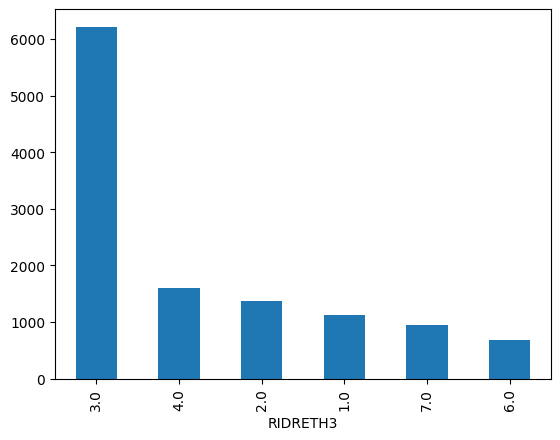

In [13]:
demo['RIDRETH3'].value_counts().plot(kind='bar')

In [14]:
# income
demo['INDFMPIR'].value_counts(dropna=False).sort_index()

INDFMPIR
5.397605e-79     100
1.000000e-02      22
2.000000e-02      29
3.000000e-02      26
4.000000e-02      17
                ... 
4.950000e+00       1
4.970000e+00       7
4.990000e+00       2
5.000000e+00    2149
NaN             2041
Name: count, Length: 472, dtype: int64

In [15]:
demo['INDFMPIR'].nunique()

471

<Axes: xlabel='INDFMPIR', ylabel='Count'>

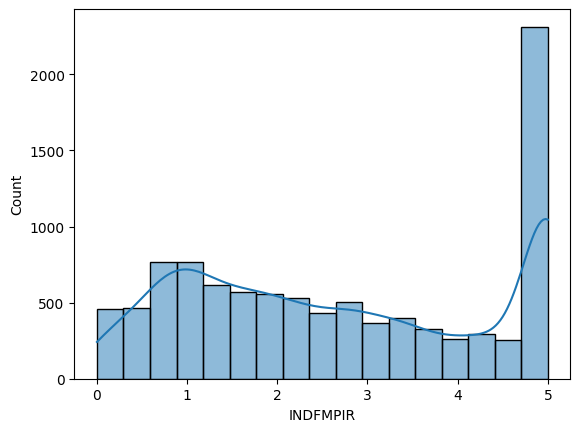

In [16]:
sns.histplot(demo['INDFMPIR'],kde=True)

In [17]:
n = demo['INDFMPIR'].notna().sum()   

pov_level_1 = (demo['INDFMPIR'] <= 1.30).sum() / n
pov_level_2 = ((demo['INDFMPIR'] > 1.30) & (demo['INDFMPIR'] <= 1.85)).sum() / n
pov_level_3 = (demo['INDFMPIR'] > 1.85).sum() / n

print(f"1:{pov_level_1:.1%}, 2:{pov_level_2:.1%}, 3:{pov_level_3:.1%}")

1:27.4%, 2:11.7%, 3:60.8%


# 2. DPQ_L shape: (6337, 11)
## Only data from participants aged 18 and older are included in this data file.

In [18]:
depresstion=tables['DPQ_L']
depresstion.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
2,130380.0,5.397605e-79,5.397605e-79,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
3,130386.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
4,130387.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN


In [19]:
depresstion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEQN    6337 non-null   float64
 1   DPQ010  5519 non-null   float64
 2   DPQ020  5518 non-null   float64
 3   DPQ030  5516 non-null   float64
 4   DPQ040  5514 non-null   float64
 5   DPQ050  5513 non-null   float64
 6   DPQ060  5510 non-null   float64
 7   DPQ070  5508 non-null   float64
 8   DPQ080  5508 non-null   float64
 9   DPQ090  5506 non-null   float64
 10  DPQ100  4167 non-null   float64
dtypes: float64(11)
memory usage: 544.7 KB


In [20]:
depresstion['DPQ010'].value_counts(dropna=False)

DPQ010
5.397605e-79    3703
1.000000e+00    1205
NaN              818
2.000000e+00     334
3.000000e+00     256
9.000000e+00      16
7.000000e+00       5
Name: count, dtype: int64

In [21]:
depresstion['DPQ010'].unique()

array([           nan, 5.39760535e-79, 3.00000000e+00, 1.00000000e+00,
       2.00000000e+00, 7.00000000e+00, 9.00000000e+00])

In [22]:
# round 0 因为xpt格式读取0显示为5.397605e-79
dpq_cols=[c for c in depresstion.columns if c.startswith('DPQ')]
depresstion[dpq_cols]=depresstion[dpq_cols].round(0)

In [23]:
depresstion['DPQ010'].value_counts(dropna=False).sort_index()

DPQ010
0.0    3703
1.0    1205
2.0     334
3.0     256
7.0       5
9.0      16
NaN     818
Name: count, dtype: int64

In [24]:
depresstion['DPQ010'].unique()

array([nan,  0.,  3.,  1.,  2.,  7.,  9.])

In [25]:
for col in dpq_cols:
    print(f"col: {col}\n")
    print(depresstion[col].value_counts(dropna=False).sort_index())

col: DPQ010

DPQ010
0.0    3703
1.0    1205
2.0     334
3.0     256
7.0       5
9.0      16
NaN     818
Name: count, dtype: int64
col: DPQ020

DPQ020
0.0    3674
1.0    1325
2.0     295
3.0     214
7.0       3
9.0       7
NaN     819
Name: count, dtype: int64
col: DPQ030

DPQ030
0.0    2772
1.0    1690
2.0     511
3.0     536
7.0       3
9.0       4
NaN     821
Name: count, dtype: int64
col: DPQ040

DPQ040
0.0    2348
1.0    2113
2.0     571
3.0     474
7.0       3
9.0       5
NaN     823
Name: count, dtype: int64
col: DPQ050

DPQ050
0.0    3710
1.0    1138
2.0     371
3.0     291
9.0       3
NaN     824
Name: count, dtype: int64
col: DPQ060

DPQ060
0.0    3971
1.0    1054
2.0     268
3.0     212
7.0       3
9.0       2
NaN     827
Name: count, dtype: int64
col: DPQ070

DPQ070
0.0    4036
1.0     989
2.0     277
3.0     203
7.0       2
9.0       1
NaN     829
Name: count, dtype: int64
col: DPQ080

DPQ080
0.0    4748
1.0     511
2.0     129
3.0     108
7.0       4
9.0       8
NaN     82

In [26]:
# convert 7 refused and 9 don't know to NaN
depresstion_clean=depresstion.copy()
for col in dpq_cols:
    depresstion_clean[col]=depresstion_clean[col].replace([7,9],np.nan)

In [27]:
for col in dpq_cols:
    print(depresstion_clean[col].value_counts(dropna=False).sort_index())

DPQ010
0.0    3703
1.0    1205
2.0     334
3.0     256
NaN     839
Name: count, dtype: int64
DPQ020
0.0    3674
1.0    1325
2.0     295
3.0     214
NaN     829
Name: count, dtype: int64
DPQ030
0.0    2772
1.0    1690
2.0     511
3.0     536
NaN     828
Name: count, dtype: int64
DPQ040
0.0    2348
1.0    2113
2.0     571
3.0     474
NaN     831
Name: count, dtype: int64
DPQ050
0.0    3710
1.0    1138
2.0     371
3.0     291
NaN     827
Name: count, dtype: int64
DPQ060
0.0    3971
1.0    1054
2.0     268
3.0     212
NaN     832
Name: count, dtype: int64
DPQ070
0.0    4036
1.0     989
2.0     277
3.0     203
NaN     832
Name: count, dtype: int64
DPQ080
0.0    4748
1.0     511
2.0     129
3.0     108
NaN     841
Name: count, dtype: int64
DPQ090
0.0    5207
1.0     209
2.0      57
3.0      28
NaN     836
Name: count, dtype: int64
DPQ100
0.0    2573
1.0    1306
2.0     207
3.0      74
NaN    2177
Name: count, dtype: int64


In [28]:
# get total_mark from dpq9, not include dpq100
dpq_9items=[f'DPQ0{i}0' for i in range(1,10)]
depresstion_clean['total']=depresstion_clean[dpq_9items].sum(axis=1,min_count=9)



In [29]:
depresstion_clean.head(15)

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100,total
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,130380.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,130386.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,130387.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
5,130388.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,130389.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
7,130390.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,130391.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,1.0,2.0,24.0
9,130392.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [30]:
# verify any dpq_9items has NaN, the total is NaN
depresstion_clean[depresstion_clean[dpq_9items].isna().sum(axis=1).between(1,8)]

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100,total
175,130704.0,1.0,2.0,1.0,NaN,1.0,1.0,1.0,2.0,0.0,1.0,NaN
207,130771.0,0.0,NaN,NaN,NaN,0.0,0.0,3.0,0.0,0.0,0.0,NaN
256,130863.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
389,131097.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
419,131157.0,0.0,0.0,2.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5509,140746.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN
5538,140799.0,0.0,NaN,1.0,NaN,NaN,2.0,3.0,NaN,NaN,1.0,NaN
5563,140844.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5787,141238.0,NaN,0.0,0.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,NaN


In [31]:
depresstion_clean['total'].describe()

count    5455.000000
mean        4.133272
std         4.765574
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        26.000000
Name: total, dtype: float64

In [32]:
depresstion_clean['total'].median()

2.0

<Axes: xlabel='total'>

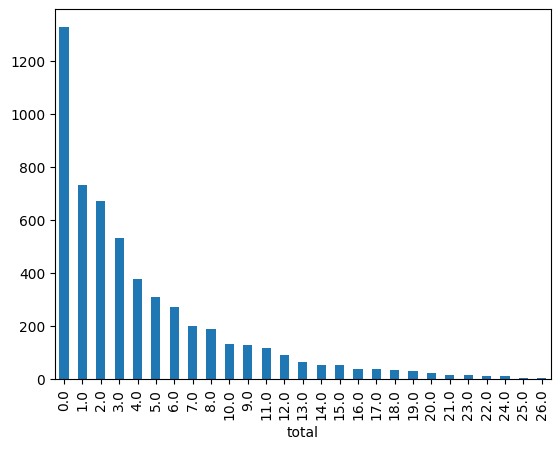

In [33]:
depresstion_clean['total'].value_counts().plot(kind='bar')

In [34]:
high_risk =(depresstion_clean['total']>=10).sum()
percent=high_risk /(depresstion_clean['total'].notna().sum())
print(f"high risk num: {high_risk }\n percent:{percent:.2%}")

high risk num: 723
 percent:13.25%


# 3.SLQ_L	Sleep Disorders (8501, 7)

In [35]:
sleep=tables['SLQ_L']
sleep.head()

,SEQN,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013
0,130378.0,21:30,07:00,9.5,00:00,09:00,9.0
1,130379.0,21:00,06:00,9.0,21:00,06:00,9.0
2,130380.0,00:00,08:00,8.0,00:00,09:00,9.0
3,130384.0,21:30,05:00,7.5,23:00,07:00,8.0
4,130385.0,22:05,06:15,8.0,22:05,06:15,8.0


In [36]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8501 entries, 0 to 8500
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEQN    8501 non-null   float64
 1   SLQ300  8501 non-null   object 
 2   SLQ310  8501 non-null   object 
 3   SLD012  8388 non-null   float64
 4   SLQ320  8501 non-null   object 
 5   SLQ330  8501 non-null   object 
 6   SLD013  8387 non-null   float64
dtypes: float64(3), object(4)
memory usage: 465.0+ KB


In [37]:
sleep['SLD012'].value_counts(dropna=False).sort_index()

SLD012
2.0       33
3.0       43
3.5       27
4.0      125
4.5       58
5.0      277
5.5      165
6.0      586
6.5      422
7.0     1218
7.5      905
8.0     1729
8.5      770
9.0      990
9.5      248
10.0     410
10.5      72
11.0     165
11.5      20
12.0      50
12.5       9
13.0      26
13.5       3
14.0      37
NaN      113
Name: count, dtype: int64

<Axes: xlabel='SLD012'>

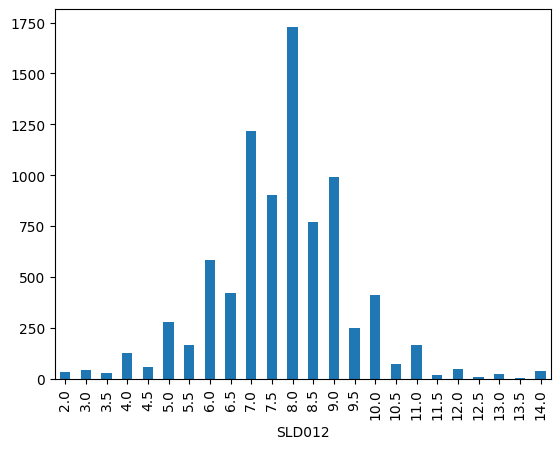

In [38]:
sleep['SLD012'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='SLD013'>

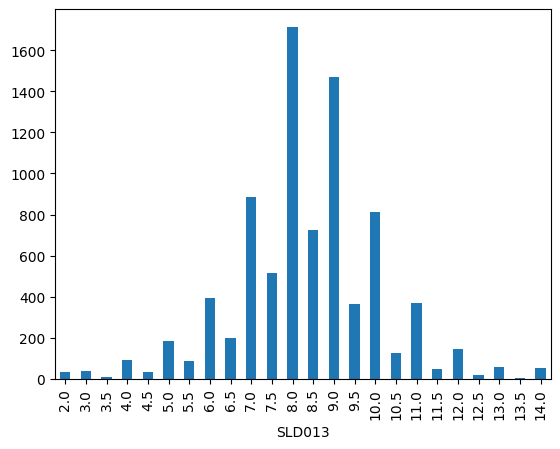

In [39]:
sleep['SLD013'].value_counts().sort_index().plot(kind='bar')

<Axes: >

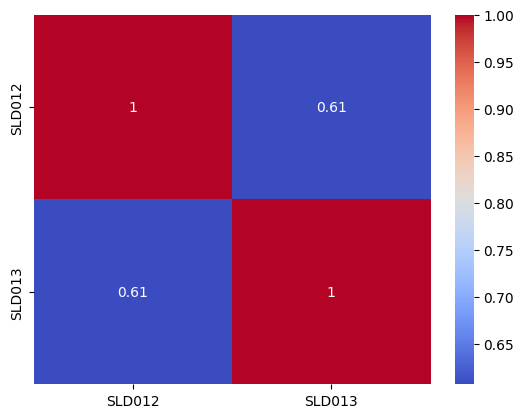

In [40]:
corr= sleep[['SLD012','SLD013']].corr()
sns.heatmap(corr,cmap='coolwarm',annot=True)

<Axes: >

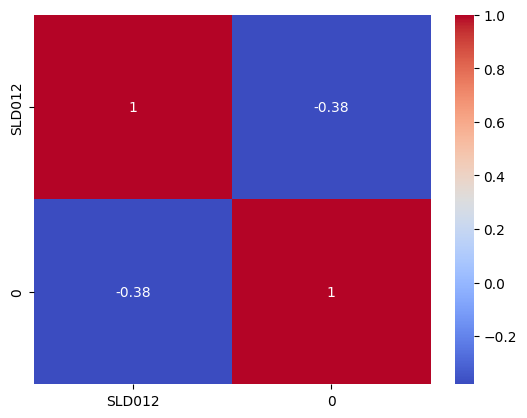

In [41]:
x=pd.concat([sleep['SLD012'],sleep['SLD013']-sleep['SLD012']],axis=1)
corr= x.corr()
sns.heatmap(corr,cmap='coolwarm',annot=True)

In [42]:
sleep['SLD012'].corr(sleep['SLD013']-sleep['SLD012'])

-0.37975426104080584

# 4.PAQ_L Physical Activity(8153, 8)
久坐 以及一个合并的周运动分钟时间 高强度和中强度加权

In [43]:
paq=tables['PAQ_L']
paq.head()

,SEQN,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,3.000000e+00,W,45.0,3.000000e+00,W,45.0,360.0
1,130379.0,4.000000e+00,W,45.0,3.000000e+00,W,45.0,480.0
2,130380.0,1.000000e+00,W,20.0,5.397605e-79,,NaN,240.0
3,130384.0,5.397605e-79,,NaN,5.397605e-79,,NaN,60.0
4,130385.0,1.000000e+00,D,90.0,1.000000e+00,W,60.0,180.0


In [44]:
paq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8153 entries, 0 to 8152
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SEQN     8153 non-null   float64
 1   PAD790Q  8135 non-null   float64
 2   PAD790U  8153 non-null   object 
 3   PAD800   6390 non-null   float64
 4   PAD810Q  8139 non-null   float64
 5   PAD810U  8153 non-null   object 
 6   PAD820   3687 non-null   float64
 7   PAD680   8138 non-null   float64
dtypes: float64(6), object(2)
memory usage: 509.7+ KB


In [45]:
paq['PAD800'].round(0).unique()

array([4.500e+01, 2.000e+01,       nan, 9.000e+01, 3.000e+01, 1.800e+02,
       6.000e+01, 1.000e+01, 1.500e+01, 1.200e+02, 5.000e+01, 4.000e+01,
       7.000e+01, 2.900e+01, 2.500e+01, 1.500e+02, 5.000e+00, 1.000e+00,
       1.050e+02, 3.000e+02, 9.999e+03, 4.200e+02, 4.800e+02, 7.500e+01,
       1.800e+01, 1.100e+01, 3.600e+02, 2.400e+02, 3.500e+01, 3.000e+00,
       2.000e+00, 6.500e+01, 6.000e+02, 8.000e+01, 5.500e+01, 7.200e+02,
       1.100e+02, 6.000e+00, 1.600e+01, 2.400e+01, 4.000e+00, 2.300e+01,
       2.700e+01, 1.400e+01, 1.200e+01, 1.000e+02, 1.150e+02, 5.400e+02,
       2.100e+01, 3.600e+01, 7.000e+00, 3.700e+01, 9.500e+01, 3.900e+01,
       3.100e+01, 4.900e+01, 6.600e+02, 8.000e+00])

In [46]:
paq['PAD800'].nunique()

57

In [47]:
paq['PAD800'].describe()

count    6390.000000
mean       93.437715
std       544.415142
min         1.000000
25%        30.000000
50%        60.000000
75%        60.000000
max      9999.000000
Name: PAD800, dtype: float64

In [48]:
paq_clean=paq.copy()
paq_clean['PAD800']=paq_clean['PAD800'].replace([7777,9999],np.nan)

<Axes: xlabel='PAD800', ylabel='Count'>

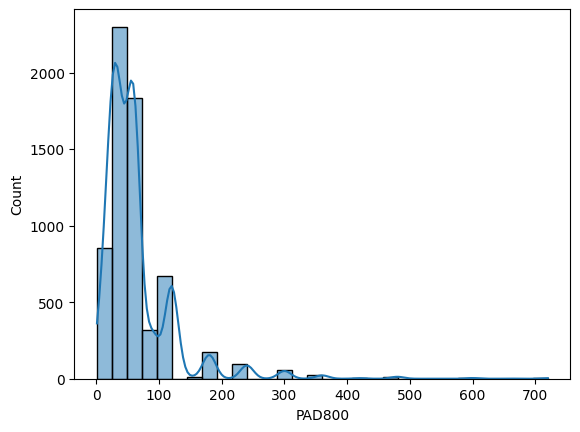

In [49]:
sns.histplot(paq_clean['PAD800'],bins=30, kde=True)

In [50]:
for i in paq_clean.columns:
    if i!='SEQN':
        print(paq_clean[i].nunique())

27
5
56
24
5
41
52


In [51]:
paq_clean['PAD680'].nunique()

52

In [52]:
paq_clean['PAD680']=paq_clean['PAD680'].replace([7777,9999],np.nan)

<Axes: xlabel='PAD680', ylabel='Count'>

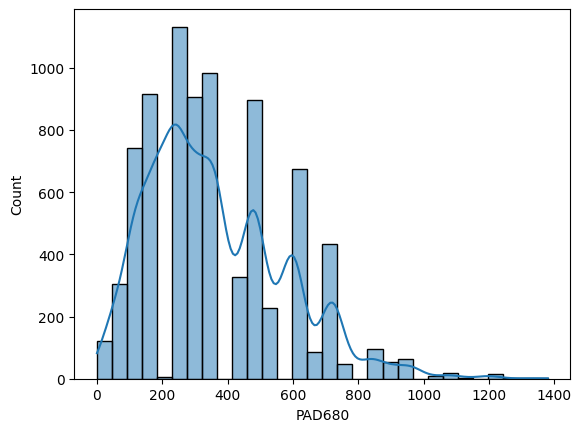

In [53]:
sns.histplot(paq_clean['PAD680'],bins=30,kde=True)

In [54]:
paq_clean['PAD680'].nlargest(5)

2234    1380.0
5670    1380.0
1736    1320.0
2531    1320.0
5707    1260.0
Name: PAD680, dtype: float64

# 5.ALQ_L	Alcohol Use (6337, 9)

In [55]:
alq=tables['ALQ_L']
alq.head()

,SEQN,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ151,ALQ170
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,1.0,2.000000e+00,3.0,5.397605e-79,NaN,NaN,2.0,NaN
2,130380.0,1.0,1.000000e+01,1.0,5.397605e-79,NaN,NaN,2.0,NaN
3,130386.0,1.0,4.000000e+00,2.0,1.000000e+01,5.397605e-79,10.0,2.0,5.397605e-79
4,130387.0,1.0,5.397605e-79,NaN,NaN,NaN,NaN,2.0,NaN


In [56]:
alq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEQN    6337 non-null   float64
 1   ALQ111  5481 non-null   float64
 2   ALQ121  4922 non-null   float64
 3   ALQ130  4069 non-null   float64
 4   ALQ142  4082 non-null   float64
 5   ALQ270  2366 non-null   float64
 6   ALQ280  2362 non-null   float64
 7   ALQ151  4901 non-null   float64
 8   ALQ170  2358 non-null   float64
dtypes: float64(9)
memory usage: 445.7 KB


In [57]:
alq['ALQ111'].value_counts(dropna=False).sort_index()

ALQ111
1.0    4918
2.0     558
9.0       5
NaN     856
Name: count, dtype: int64

In [58]:
alq['ALQ111'].isnull().sum()

856

In [59]:
alq['ALQ121'].value_counts(dropna=False).sort_index()

ALQ121
5.397605e-79     836
1.000000e+00     163
2.000000e+00     301
3.000000e+00     458
4.000000e+00     483
5.000000e+00     420
6.000000e+00     574
7.000000e+00     362
8.000000e+00     261
9.000000e+00     517
1.000000e+01     542
7.700000e+01       2
9.900000e+01       3
NaN             1415
Name: count, dtype: int64

# 6. SMQ_L	Smoking – Cigarette Use (9015, 9)

In [60]:
smq=tables['SMQ_L']
smq.head()

,SEQN,SMQ020,SMQ040,SMD641,SMD650,SMD100MN,SMQ621,SMD630,SMAQUEX2
0,130378.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
1,130379.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
2,130380.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,130384.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,130385.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0


<Axes: xlabel='SMQ020'>

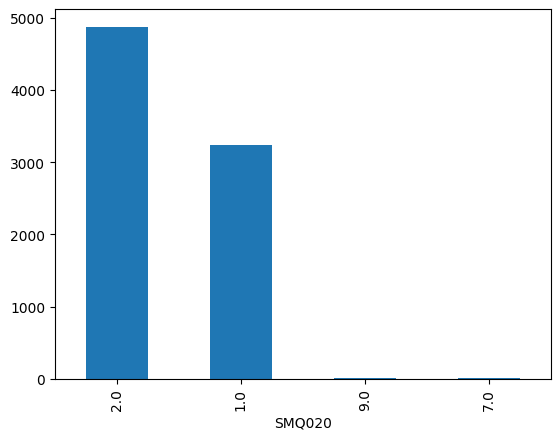

In [61]:
smq['SMQ020'].value_counts().plot(kind='bar')

<Axes: xlabel='SMQ020', ylabel='Count'>

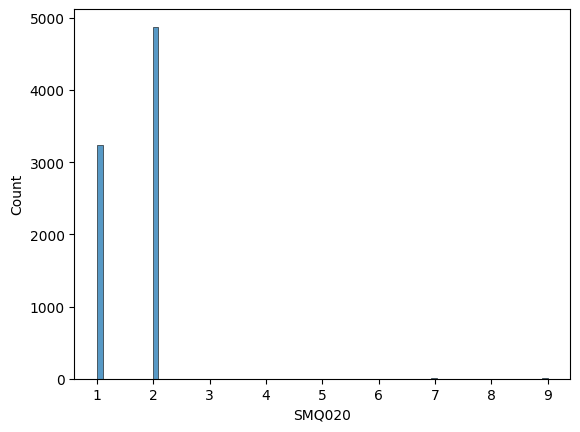

In [62]:
sns.histplot(smq['SMQ020'])

# 7. INQ_L	Income (11933, 5)

In [63]:
inq=tables['INQ_L']
inq.head()

,SEQN,INDFMMPI,INDFMMPC,INQ300,IND310
0,130378.0,5.00,3.0,1.0,NaN
1,130379.0,5.00,3.0,1.0,NaN
2,130380.0,1.40,2.0,2.0,1.0
3,130381.0,0.33,1.0,2.0,1.0
4,130382.0,4.32,3.0,1.0,NaN


In [64]:
n=inq['INDFMMPC'].notna().sum()
print((inq['INDFMMPC']==1).sum()/n)
print((inq['INDFMMPC']==2).sum()/n)
print((inq['INDFMMPC']==3).sum()/n)

0.28631498470948014
0.1470756880733945
0.5409021406727829


In [65]:
inq['INQ300'].describe()

count    10468.000000
mean         1.796141
std          1.299623
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          9.000000
Name: INQ300, dtype: float64

In [66]:
inq['INQ300'].unique()

array([ 1.,  2., nan,  9.,  7.])

<Axes: xlabel='INQ300', ylabel='count'>

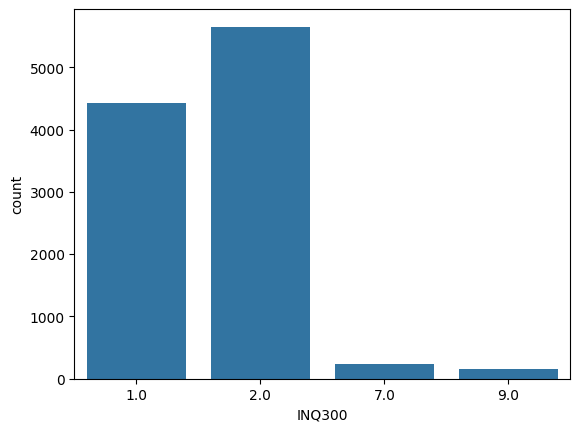

In [67]:
sns.countplot(data=inq, x='INQ300')

# 8. HIQ_L	Health Insurance (11933, 11)

In [68]:
hiq=tables['HIQ_L']
hiq.head()

,SEQN,HIQ011,HIQ032A,HIQ032B,HIQ032C,HIQ032D,HIQ032E,HIQ032F,HIQ032H,HIQ032I,HIQ210
0,130378.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
1,130379.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0
2,130380.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,1.0
3,130381.0,1.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,2.0
4,130382.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [69]:


hiq['HIQ011'].value_counts(dropna=False).sort_index()

HIQ011
1.0    11007
2.0      864
7.0       10
9.0       29
NaN       23
Name: count, dtype: int64

In [70]:
hiq['HIQ210'].value_counts(dropna=False).sort_index()

HIQ210
1.0      455
2.0    10529
7.0        2
9.0       19
NaN      928
Name: count, dtype: int64

# 9.DIQ_L	Diabetes (11744, 9)

In [71]:
diq=tables['DIQ_L']
diq.head()

,SEQN,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
diq["DIQ010"].value_counts().sort_index()

DIQ010
1.0     1081
2.0    10371
3.0      284
9.0        4
Name: count, dtype: int64

# 10 BMX_L	Body Measures (8860, 22)

In [73]:
bmx=tables['BMX_L']
bmx.head()

,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,130378.0,1.0,86.9,NaN,NaN,NaN,NaN,NaN,179.5,NaN,...,42.8,NaN,42.0,NaN,35.7,NaN,98.3,NaN,102.9,NaN
1,130379.0,1.0,101.8,NaN,NaN,NaN,NaN,NaN,174.2,NaN,...,38.5,NaN,38.7,NaN,33.7,NaN,114.7,NaN,112.4,NaN
2,130380.0,1.0,69.4,NaN,NaN,NaN,NaN,NaN,152.9,NaN,...,38.5,NaN,35.5,NaN,36.3,NaN,93.5,NaN,98.0,NaN
3,130381.0,1.0,34.3,NaN,NaN,NaN,NaN,NaN,120.1,NaN,...,NaN,NaN,25.4,NaN,23.4,NaN,70.4,NaN,NaN,NaN
4,130382.0,3.0,13.6,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN


In [74]:
bmx.columns

Index(['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD',
       'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG',
       'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST',
       'BMXHIP', 'BMIHIP'],
      dtype='object')

<Axes: xlabel='BMXBMI', ylabel='Count'>

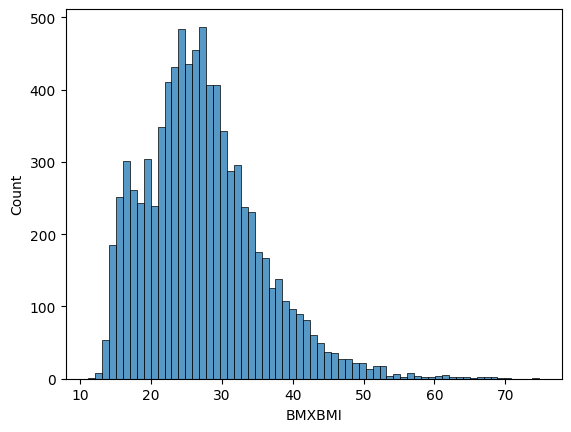

In [75]:
sns.histplot(data=bmx,x='BMXBMI')

In [76]:
bmx['BMXBMI'].describe()

count    8471.000000
mean       27.246665
std         8.137781
min        11.100000
25%        21.600000
50%        26.400000
75%        31.700000
max        74.800000
Name: BMXBMI, dtype: float64

In [77]:
bmx['BMXBMI'].value_counts(dropna=False).sort_index()

BMXBMI
11.1      1
12.4      1
12.5      2
12.7      1
12.9      3
       ... 
68.9      1
69.1      1
69.9      1
74.8      1
NaN     389
Name: count, Length: 452, dtype: int64

In [78]:
bmx['BMXWAIST'].describe()

count    8190.000000
mean       92.120830
std        22.050484
min        39.800000
25%        77.500000
50%        92.700000
75%       107.000000
max       187.000000
Name: BMXWAIST, dtype: float64

In [79]:
bmx['BMXHT'].describe()

count    8499.000000
mean      159.664549
std        19.864943
min        79.100000
25%       154.400000
50%       163.600000
75%       172.100000
max       200.700000
Name: BMXHT, dtype: float64

<Axes: xlabel='BMXWAIST', ylabel='Count'>

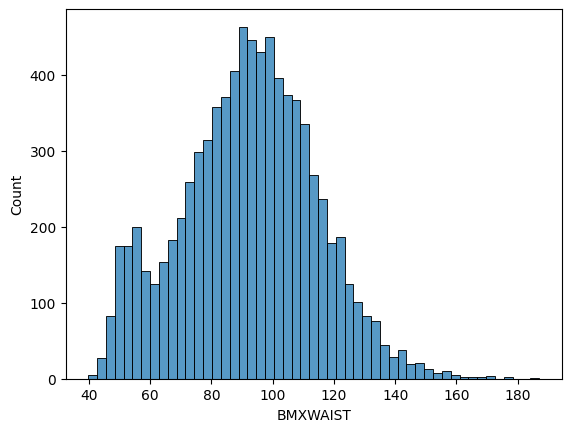

In [80]:
sns.histplot(data=bmx,x='BMXWAIST')

<Axes: xlabel='BMXHT', ylabel='Count'>

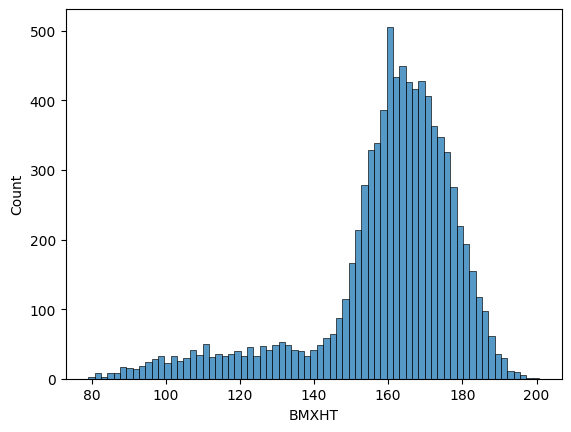

In [81]:
sns.histplot(data=bmx,x='BMXHT')

# 11. merge  attempt

From handled DPQ_L 5455 records left join all tables

In [82]:
depresstion_valid=depresstion_clean[depresstion_clean['total'].notna()]

In [83]:
len(depresstion_valid)

5455

In [84]:
depresstion_valid.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100,total
1,130379.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,130380.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,130386.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,130387.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
6,130389.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [85]:
merge_tables_name=[i for i in TABLE_NAMES if i !='DPQ_L']
merged=depresstion_valid
for t in merge_tables_name:
    right=tables[t]
    merged = merged.merge(right, on="SEQN", how="left")
    print(f'after merge {t}, len:{len(merged)}')

print(f'finalize shape: {merged.shape}')


after merge DEMO_L, len:5455
after merge SLQ_L, len:5455
after merge PAQ_L, len:5455
after merge ALQ_L, len:5455
after merge SMQ_L, len:5455
after merge INQ_L, len:5455
after merge HIQ_L, len:5455
after merge DIQ_L, len:5455
after merge BMX_L, len:5455
finalize shape: (5455, 110)


In [86]:
merge_tables_name=[i for i in TABLE_NAMES if i !='DPQ_L']
merged_inner=depresstion_valid
for t in merge_tables_name:
    right=tables[t]
    merged_inner = merged_inner.merge(right, on="SEQN", how="inner")
    print(f'after merge {t}, len:{len(merged_inner)}')

print(f'finalize shape: {merged_inner.shape}')

after merge DEMO_L, len:5455
after merge SLQ_L, len:5455
after merge PAQ_L, len:5455
after merge ALQ_L, len:5455
after merge SMQ_L, len:5455
after merge INQ_L, len:5455
after merge HIQ_L, len:5455
after merge DIQ_L, len:5455
after merge BMX_L, len:5455
finalize shape: (5455, 110)


# 12. sensitive_subgroup distribution  gender、race、income

In [87]:
merged.columns

Index(['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060',
       'DPQ070', 'DPQ080', 'DPQ090',
       ...
       'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC',
       'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP'],
      dtype='object', length=110)

In [ ]:
merged['depressed']= merged['total']>=10

In [95]:
# gender
tab1=pd.crosstab(merged["RIAGENDR"].map({1: "Male", 2: "Female"}),
                merged['depressed'].map({True: "Yes", False: "No"}),normalize='index')

print(tab1)

depressed        No       Yes
RIAGENDR                     
Female     0.845013  0.154987
Male       0.894250  0.105750


In [103]:
# race 
# 1	Mexican American 2	Other Hispanic 3	Non-Hispanic White  4	Non-Hispanic Black  6	Non-Hispanic Asian 7	Other Race - Including Multi-Racial
# demo['RIDRETH3'].value_counts().sort_index()
race_map={1:"Mexican American",2:"Other Hispanic",3:"Non-Hispanic White" ,4:"Non-Hispanic Black" ,6:"Non-Hispanic Asian",7:"Other Race"}

tab2=pd.crosstab(merged["RIDRETH3"].map(race_map),
                merged['depressed'].map({True: "Yes", False: "No"}),normalize='index')

print(tab2)

depressed                 No       Yes
RIDRETH3                              
Mexican American    0.840541  0.159459
Non-Hispanic Asian  0.918699  0.081301
Non-Hispanic Black  0.852615  0.147385
Non-Hispanic White  0.876320  0.123680
Other Hispanic      0.863894  0.136106
Other Race          0.810440  0.189560


In [97]:
# income
# 收入可以分箱成3类 INDFMPIR
# Low (贫困/近贫困)<= 1.3贫困线 130% 以下，常用的低收入门槛Middle1.3 – 1.85        High> 1.85

merged['income_group']=pd.cut(merged['INDFMPIR'],bins=[-np.inf,1.3,1.85,np.inf],labels=['Low','Medium','High'])


In [99]:
print(merged['income_group'].value_counts(dropna=False))

income_group
High      3270
Low       1025
NaN        658
Medium     502
Name: count, dtype: int64


In [101]:
tab3=pd.crosstab(merged['income_group'],merged['depressed'].map({True: "Yes", False: "No"}),margins=True)
tab3

depressed,No,Yes,All
income_group,,,
Low,797,228,1025
Medium,398,104,502
High,2954,316,3270
All,4149,648,4797
